In [43]:
from tensorflow.keras.models import load_model
import segmentation_models as sm
import tensorflow as tf

# Load without recompiling (no need for loss during prediction)
model = load_model("my_model.h5",
                   custom_objects={"jeccard_coef": jeccard_coef},
                   compile=False)

# Predict
predictions = model.predict(x_test)  # shape: (num_samples, H, W, num_classes)

# Convert probabilities to class labels
predicted_masks = np.argmax(predictions, axis=-1)  # shape: (num_samples, H, W)

5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step


In [44]:
y_test_arg_max=np.argmax(y_test,axis=3)

In [45]:
len(predicted_masks)

142

In [46]:
len(y_test)

142

In [49]:
y_test_arg_max

array([[[3, 3, 3, ..., 1, 1, 1],
        [3, 3, 3, ..., 3, 3, 3],
        [3, 3, 3, ..., 3, 3, 3],
        ...,
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[2, 2, 2, ..., 1, 1, 1],
        [2, 2, 2, ..., 1, 1, 1],
        [2, 2, 2, ..., 1, 1, 1],
        ...,
        [2, 2, 2, ..., 0, 0, 0],
        [2, 2, 2, ..., 0, 0, 0],
        [2, 2, 1, ..., 0, 0, 0]],

       ...,

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [48]:
predicted_masks

array([[[2, 2, 2, ..., 2, 2, 1],
        [1, 1, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        ...,
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 3, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [4, 4, 4, ..., 4, 4, 4],
        [4, 4, 4, ..., 4, 4, 4],
        [4, 4, 4, ..., 4, 4, 4]],

       ...,

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 4, 4, 4],
        [1, 1, 1, ..., 4, 4, 4],
        [1, 1, 1, ..., 4, 4, 4]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


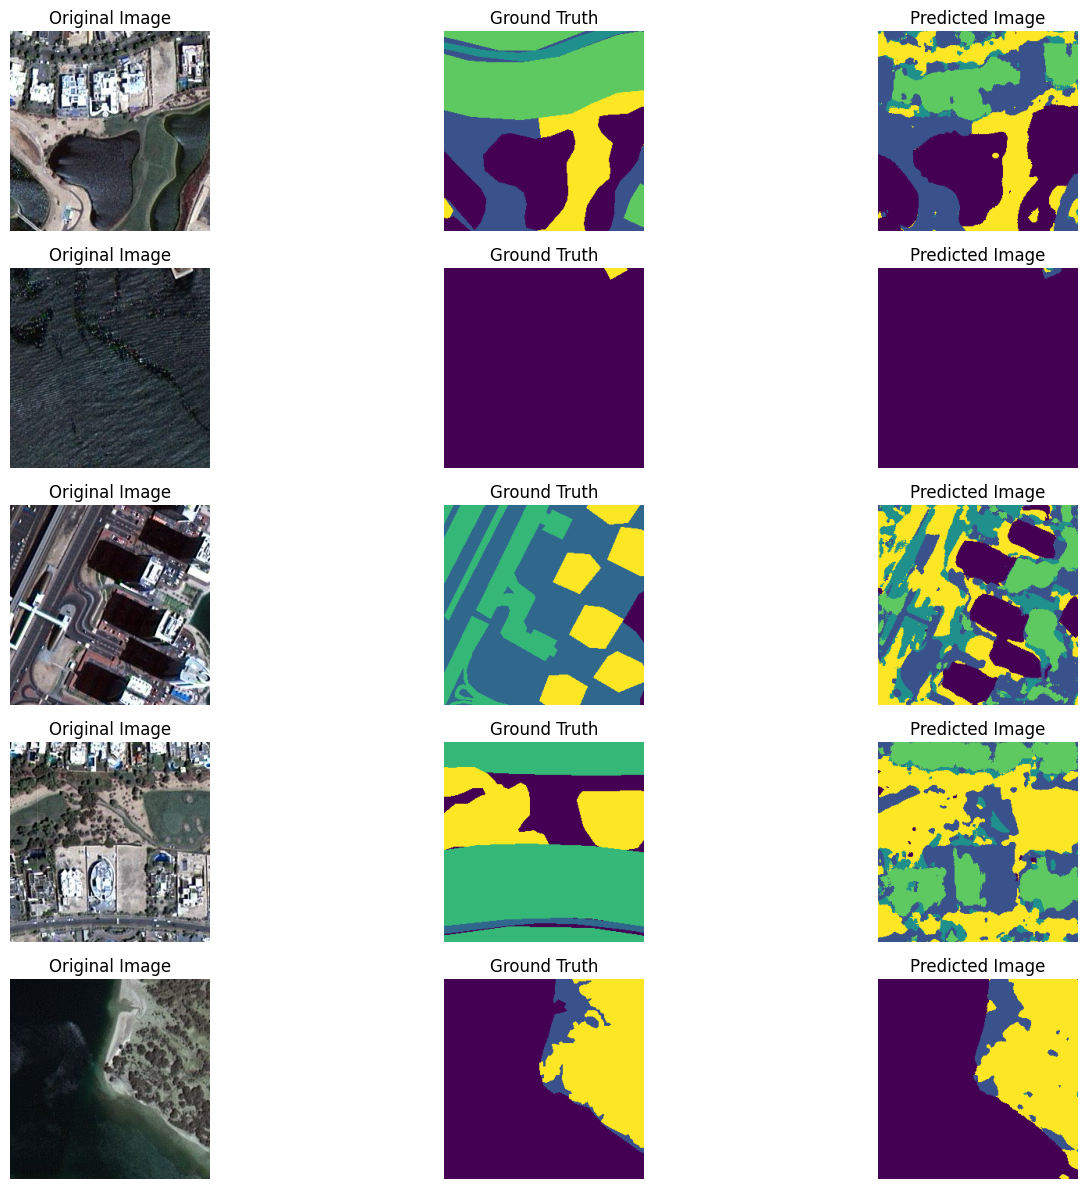

In [56]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 12))

for i in range(5):
    x_test_image = x_test[i]
    ground_truth_image = y_test_arg_max[i]

    prediction = model.predict(np.expand_dims(x_test_image, 0))
    predicted_image = np.argmax(prediction, axis=3)
    predicted_image = predicted_image[0, :, :]

    # Original Image
    plt.subplot(5, 3, i*3 + 1)
    plt.title("Original Image")
    plt.imshow(x_test_image.astype('float32')) # Cast to float32
    plt.axis('off')

    # Ground Truth
    plt.subplot(5, 3, i*3 + 2)
    plt.title("Ground Truth")
    plt.imshow(ground_truth_image)
    plt.axis('off')

    # Predicted Image
    plt.subplot(5, 3, i*3 + 3)
    plt.title("Predicted Image")
    plt.imshow(predicted_image)
    plt.axis('off')

plt.tight_layout()
plt.show()

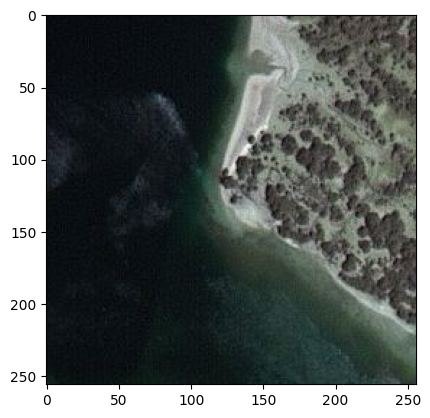

In [52]:
plt.imshow(x_test_image.astype('float32'))

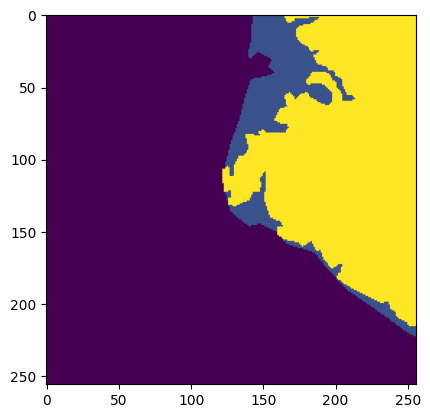

In [53]:
plt.imshow(ground_truth_image)

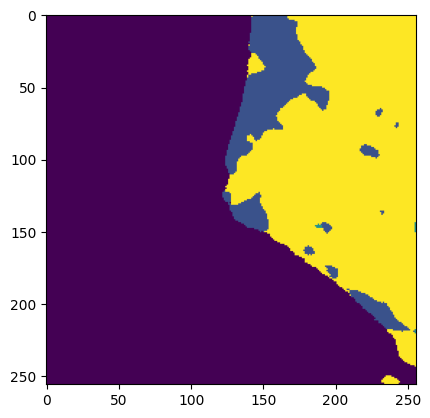

In [54]:
plt.imshow(predicted_image)